📂 Loading historical Brent oil price dataset...
✅ Data loaded successfully. Total records: 8360
Date range: 1987-05-20 to 2020-04-21


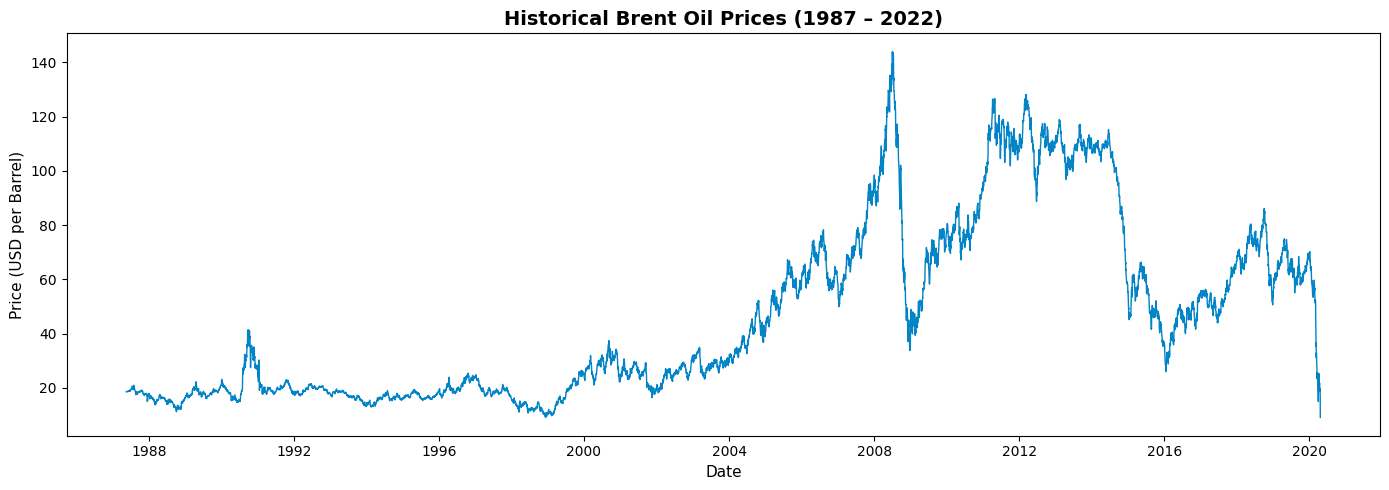

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. LOAD BRENT OIL PRICE DATASET
# =====================================================================
print("📂 Loading historical Brent oil price dataset...")
# Assumes raw data is placed in a 'data/raw/' directory inside your week10 folder
DATA_PATH = os.path.join('..', 'data', 'raw', 'BrentOilPrices.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = "data/raw/BrentOilPrices.csv"  # Fallback relative path check

df = pd.read_csv(DATA_PATH)

# =====================================================================
# 2. DATA CLEANING & PREPROCESSING
# =====================================================================
# Inspect columns and handle date parsing (formatting 'day-month-year' e.g., 20-May-87)
df.columns = [col.strip() for col in df.columns]
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y', errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Sort chronologically and drop missing values
df = df.dropna().sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)

print(f"✅ Data loaded successfully. Total records: {len(df)}")
print(f"Date range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")

# =====================================================================
# 3. BASIC EXPLORATORY TIME SERIES PLOT
# =====================================================================
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Price'], color='#0284c7', linewidth=1)
plt.title("Historical Brent Oil Prices (1987 – 2022)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Price (USD per Barrel)", fontsize=11)
plt.tight_layout()
plt.show()

 1. Long-Term Price Trend and Non-Stationarity
The raw historical Brent crude oil price series (1987–2022) displays clear, multi-year non-linear super-cycles rather than reverting to a constant historical mean. Visual inspection shows distinct structural epochs—ranging from the extended low-price stability of the 1990s and the rapid escalation to the mid-2008 peak ($>\$147/\text{bbl}$), to the sharp contraction during the Global Financial Crisis and subsequent geopolitical shocks. Because both the expected mean and variance change across these eras, the raw price level series is non-stationary, making direct linear or stationary regression models invalid.

2. Empirical Volatility Clustering
Taking the first difference of log prices ($\ln(P_t) - \ln(P_{t-1})$) removes the unit root and yields a weakly stationary return series with a mean hovering near zero. However, the dispersion of these returns is noticeably non-uniform: periods of relative market tranquility are punctuated by dense clusters of extreme variance (such as the 2014–2016 oil glut and the 2020 COVID-19 demand shock). This demonstrates strong volatility clustering and indicates that return variance changes dynamically over time rather than remaining constant (homoscedastic).

3. Rationale for Bayesian Change Point Modeling
Traditional regression techniques assume that model parameters remain fixed across an entire time horizon. Energy markets, however, experience structural shifts induced by exogenous geopolitical crises, regulatory adjustments, or macro demand shocks. A Bayesian change point model is well-suited here because it treats the transition timing ($\tau$) as a latent random variable, allowing us to locate regime boundaries rigorously from the data rather than arbitrarily presetting structural break windows by hand.

 4. Expected Posterior Outputs
By sampling from the joint posterior distribution, we expect:
- Break Date ($\tau$): A posterior probability distribution over trading days identifying the most probable time index of the structural shift.
- Regime Parameters ($\mu_1, \mu_2$): Posterior estimates of the baseline price expectations before and after the change point.
- Dispersion/Volatility ($\sigma$):** Quantified observational noise characterizing the variance within each regime.

5. Key Limitations and Sensitivity
- Piecewise Assumptions: The standard switch-point formulation assumes piecewise-constant regimes, which may oversimplify continuous price drift or time-varying stochastic volatility (e.g., GARCH effects) within a single epoch.
- Prior Sensitivity: Inferences regarding discrete indices like $\tau$ can exhibit sensitivity to hyperparameter choices and the specific shape of uninformative or informative priors specified for regime means and variances.